# **Optimizing Two-Way partial AUC on Imbalanced CIFAR10 Dataset (SOTAs)**


**Author**: Dixian Zhu \
**Edited by**: Zhuoning Yuan 

**Introduction**

In this tutorial, we will learn how to quickly train a ResNet18 model by optimizing **two way partial AUC (TPAUC)** score using our novel `tpAUC_KL_Loss` and `SOTAs` optimizer [[Ref]](https://proceedings.mlr.press/v162/zhu22g.html) method on a binary image classification task on Cifar10. After completion of this tutorial, you should be able to use LibAUC to train your own models on your own datasets.

**Reference**:
   
If you find this tutorial helpful in your work, please cite our [library paper](https://arxiv.org/abs/2306.03065) and the following papers:

```
@inproceedings{zhu2022auc,
              title={When auc meets dro: Optimizing partial auc for deep learning with non-convex convergence guarantee},
              author={Zhu, Dixian and Li, Gang and Wang, Bokun and Wu, Xiaodong and Yang, Tianbao},
              booktitle={International Conference on Machine Learning},
              pages={27548--27573},
              year={2022},
              organization={PMLR}
            }

```

# **Installing LibAUC**

Let’s start with installing our library here. In this tutorial, we will use the lastest version for LibAUC by using ``pip install -U``.

In [ ]:
!pip install -U libauc

# **Importing LibAUC**

In [ ]:
from libauc.models import resnet18
from libauc.datasets import CIFAR10
from libauc.losses import tpAUC_KL_Loss
from libauc.optimizers import SOTAs
from libauc.utils import ImbalancedDataGenerator
from libauc.sampler import DualSampler # data resampling (for binary class)
from libauc.metrics import pauc_roc_score

import torch
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import Dataset

# **Reproducibility**

These functions limit the number of sources of randomness behaviors, such as model intialization, data shuffling, etcs. However, completely reproducible results are not guaranteed across PyTorch releases [[Ref]](https://pytorch.org/docs/stable/notes/randomness.html#:~:text=Completely%20reproducible%20results%20are%20not,even%20when%20using%20identical%20seeds.).

In [ ]:
def set_all_seeds(SEED):
    # REPRODUCIBILITY
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# **Image Dataset**

Now we define the data input pipeline such as data augmentations. In this tutorials, we use ``RandomCrop``, ``RandomHorizontalFlip``. The ``pos_index_map`` helps map global index to local index for reducing memory cost in loss function since we only need to track the indices for positive samples.



In [ ]:
class ImageDataset(Dataset):
  def __init__(self, images, targets, image_size=32, crop_size=30, mode='train'):
     self.images = images.astype(np.uint8)
     self.targets = targets
     self.mode = mode
     self.transform_train = transforms.Compose([
                            transforms.ToTensor(),
                            transforms.RandomCrop((crop_size, crop_size), padding=None),
                            transforms.RandomHorizontalFlip(),
                            transforms.Resize((image_size, image_size)),
                            ])
     self.transform_test = transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Resize((image_size, image_size)),
                            ])

     # for loss function
     self.pos_indices = np.flatnonzero(targets==1)
     self.pos_index_map = {}
     for i, idx in enumerate(self.pos_indices):
         self.pos_index_map[idx] = i

  def __len__(self):
      return len(self.images)

  def __getitem__(self, idx):
      image = self.images[idx]
      target = self.targets[idx]
      image = Image.fromarray(image.astype('uint8'))
      if self.mode == 'train':
          idx = self.pos_index_map[idx] if idx in self.pos_indices else -1
          image = self.transform_train(image)
      else:
          image = self.transform_test(image)
      return image, target, idx

# **HyperParameters**

In [ ]:
# HyperParameters
SEED = 123
batch_size = 64
total_epochs = 60
weight_decay = 1e-4
lr = 1e-3
decay_epochs = [20, 40]
decay_factor = 10

gamma0 = 0.5 # learning rate for control negative samples weights
gamma1 = 0.5 # learning rate for control positive samples weights

tau = 1.0 # KL-DRO regularization for outer positive samples part  #
Lambda = 0.5 # KL-DRO regularization for inner negative samples part #

# oversampling minority class, you can tune it in (0, 0.5]
# e.g., sampling_rate=0.5 is that num of positive samples in mini-batch is sampling_rate*batch_size=32
sampling_rate = 0.5
num_pos = round(sampling_rate*batch_size)
num_neg = batch_size - num_pos

# **Loading datasets**

In [ ]:
# load data as numpy arrays
train_data, train_targets = CIFAR10(root='./data', train=True).as_array()
test_data, test_targets  = CIFAR10(root='./data', train=False).as_array()

# generate imbalanced data
generator = ImbalancedDataGenerator(shuffle=True, verbose=True, random_seed=0)
(train_images, train_labels) = generator.transform(train_data, train_targets, imratio=0.2)
(test_images, test_labels) = generator.transform(test_data, test_targets, imratio=0.5)

# data augmentations
trainDataset = ImageDataset(train_images, train_labels)
testDataset = ImageDataset(test_images, test_labels, mode='test')

# dataloaders
sampler = DualSampler(trainDataset, batch_size, sampling_rate=sampling_rate)
trainloader = torch.utils.data.DataLoader(trainDataset, batch_size, sampler=sampler, shuffle=False, num_workers=1)
testloader = torch.utils.data.DataLoader(testDataset, batch_size=batch_size, shuffle=False, num_workers=1)

Files already downloaded and verified
Files already downloaded and verified
#SAMPLES: 31250, CLASS 0.0 COUNT: 25000, CLASS RATIO: 0.8000
#SAMPLES: 31250, CLASS 1.0 COUNT: 6250, CLASS RATIO: 0.2000
#SAMPLES: 10000, CLASS 0 COUNT: 5000, CLASS RATIO: 0.5000
#SAMPLES: 10000, CLASS 1 COUNT: 5000, CLASS RATIO: 0.5000


# **Creating models & TPAUC Optimizer**

In [ ]:
# You can include sigmoid/l2 activations on model's outputs before computing loss
set_all_seeds(SEED)
model = resnet18(pretrained=False, num_classes=1, last_activation=None)
model = model.cuda()


# Initialize the loss function and optimizer
loss_fn = tpAUC_KL_Loss(data_len=sampler.pos_len, Lambda=Lambda, tau=tau, gammas=(gamma0, gamma1))
optimizer = SOTAs(model.parameters(), loss_fn=loss_fn, mode='adam', lr=lr, weight_decay=weight_decay)

# **Training**

In [ ]:
import warnings
warnings.filterwarnings("ignore")
print ('Start Training')
print ('-'*30)

tr_tpAUC=[]
te_tpAUC=[]

for epoch in range(total_epochs):
    if epoch in decay_epochs:
        optimizer.update_lr(decay_factor=decay_factor)

    train_loss = 0
    model.train()
    for idx, data in enumerate(trainloader):
        train_data, train_labels, index = data
        train_data, train_labels = train_data.cuda(), train_labels.cuda()
        y_pred = model(train_data)
        y_prob = torch.sigmoid(y_pred)
        loss = loss_fn(y_prob, train_labels, index[:num_pos])
        train_loss = train_loss  + loss.cpu().detach().numpy()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss = train_loss/(idx+1)

    # evaluation
    model.eval()
    with torch.no_grad():
        train_pred = []
        train_true = []
        for jdx, data in enumerate(trainloader):
            train_data, train_labels,_ = data
            train_data = train_data.cuda()
            y_pred = model(train_data)
            y_prob = torch.sigmoid(y_pred)
            train_pred.append(y_prob.cpu().detach().numpy())
            train_true.append(train_labels.numpy())
        train_true = np.concatenate(train_true)
        train_pred = np.concatenate(train_pred)
        single_train_auc =  pauc_roc_score(train_true, train_pred, max_fpr = 0.3, min_tpr=0.7)

        test_pred = []
        test_true = []
        for jdx, data in enumerate(testloader):
            test_data, test_labels, _ = data
            test_data = test_data.cuda()
            y_pred = model(test_data)
            y_prob = torch.sigmoid(y_pred)
            test_pred.append(y_prob.cpu().detach().numpy())
            test_true.append(test_labels.numpy())
        test_true = np.concatenate(test_true)
        test_pred = np.concatenate(test_pred)
        single_test_auc =  pauc_roc_score(test_true, test_pred, max_fpr = 0.3, min_tpr=0.7)
        print('Epoch=%s, Loss=%0.4f, Train_tpAUC(0.3,0.7)=%.4f, Test_tpAUC(0.3,0.7)=%.4f, lr=%.4f'%(epoch, train_loss, single_train_auc, single_test_auc, optimizer.lr))

        tr_tpAUC.append(single_train_auc)
        te_tpAUC.append(single_test_auc)

Start Training
------------------------------
Epoch=0, Loss=1.3559, Train_tpAUC(0.3,0.7)=0.0000, Test_tpAUC(0.3,0.7)=0.0000, lr=0.0010
Epoch=1, Loss=0.9319, Train_tpAUC(0.3,0.7)=0.0238, Test_tpAUC(0.3,0.7)=0.0072, lr=0.0010
Epoch=2, Loss=0.8985, Train_tpAUC(0.3,0.7)=0.0201, Test_tpAUC(0.3,0.7)=0.0076, lr=0.0010
Epoch=3, Loss=0.8669, Train_tpAUC(0.3,0.7)=0.1492, Test_tpAUC(0.3,0.7)=0.0692, lr=0.0010
Epoch=4, Loss=0.8389, Train_tpAUC(0.3,0.7)=0.1715, Test_tpAUC(0.3,0.7)=0.1109, lr=0.0010
Epoch=5, Loss=0.8074, Train_tpAUC(0.3,0.7)=0.2485, Test_tpAUC(0.3,0.7)=0.1212, lr=0.0010
Epoch=6, Loss=0.7615, Train_tpAUC(0.3,0.7)=0.1549, Test_tpAUC(0.3,0.7)=0.0624, lr=0.0010
Epoch=7, Loss=0.7338, Train_tpAUC(0.3,0.7)=0.3678, Test_tpAUC(0.3,0.7)=0.2257, lr=0.0010
Epoch=8, Loss=0.7005, Train_tpAUC(0.3,0.7)=0.4222, Test_tpAUC(0.3,0.7)=0.1703, lr=0.0010
Epoch=9, Loss=0.6752, Train_tpAUC(0.3,0.7)=0.5709, Test_tpAUC(0.3,0.7)=0.2833, lr=0.0010
Epoch=10, Loss=0.6236, Train_tpAUC(0.3,0.7)=0.6198, Test_tpAUC(0

# **Visualization**

Text(0.5, 0, 'epochs')

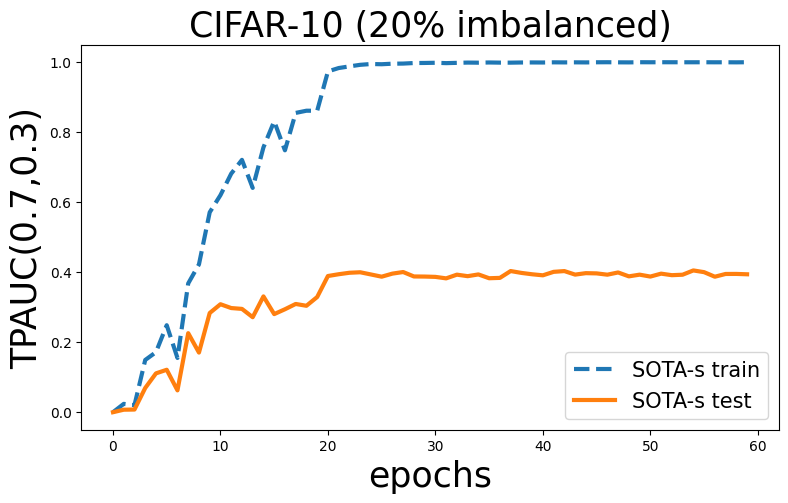

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(60)

plt.figure()
plt.plot(x, tr_tpAUC, linestyle='--', label='SOTA-s train', linewidth=3)
plt.plot(x, te_tpAUC, label='SOTA-s test', linewidth=3)
plt.title('CIFAR-10 (20% imbalanced)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('TPAUC(0.7,0.3)',fontsize=25)
plt.xlabel('epochs',fontsize=25)